<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/lap2_IPipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1.1 Simulation mach bands**

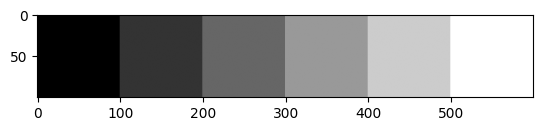

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bands = np.zeros((100,600))

for i in range(6):
   bands[: , i*100:(i+1)*100] = i*40

plt.imshow(bands , cmap= 'gray')
plt.axis ('on')
plt.show()
#1.	Do the boundaries between bands appear sharper than the interiors?
#yes

#2.	Are these sharp transitions present in the data or only in perception?
#no there are not present in the data; they are only a perceptual effect.


# 2.1 brightness

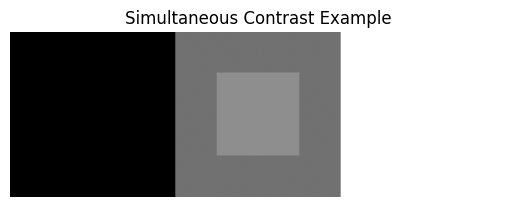

In [ ]:
img = np.ones ((200, 600)) * 100
img[:, : 200] = 20
img[:, 400 :] = 200
img[50:150, 250:350] = 120
plt. imshow (img, cmap='gray')
plt.title("Simultaneous Contrast Example")
plt.axis ('off')
plt.show ()

#1.	Does the central rectangle appear equally bright on both backgrounds?
#no

#2.	What does this imply for interpreting pixel values visually?
#This implies that perceived brightness depends on surrounding context, so pixel values alone do not determine how bright something appears visually

# 3.1 inspecting

(256, 256)
0 255


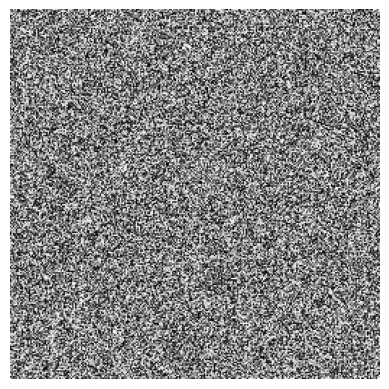

In [ ]:
image = np.random.randint(0,256,(256,256))
print(image.shape)
print(image.min(),image.max())

plt. imshow (image, cmap='gray')
plt.axis ('off')
plt.show ()

#Explain how this array corresponds to f(x, y) as defined in the lecture.
#The array represents the image as a function f(x, y), where each element at position (x, y) is a pixel value between 0 and 255 indicating the intensity at that location.

# Exercise 4.1: Down sampling an image

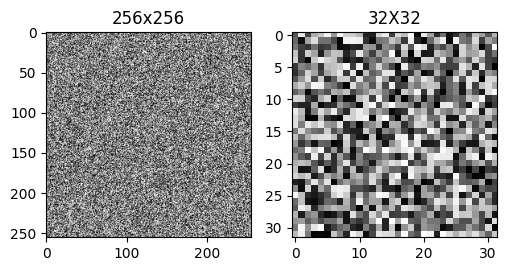

In [ ]:
original = image.copy ()
down_64 = original[::4, ::4]
down_32 = original[::8, ::8]

plt.figure (figsize= (9,3))
plt.subplot (1,3,1)
plt.imshow(original, cmap='gray')

plt.title('256x256')
plt.subplot (1,3,2)
plt.imshow(down_64 ,cmap='gray')
plt.title('64x64')

plt.subplot (1,3,2)
plt.imshow(down_32 ,cmap='gray')
plt.title('32X32')

plt.show()

#1.	Which image shows the greatest loss of detail?
#The 32×32 image shows the greatest loss of detail.

#2.	Has the number of grey levels changed?
#No, the number of grey levels has not changed; only the spatial resolution has decreased.

# Exercise 5.1: Reducing grey levels

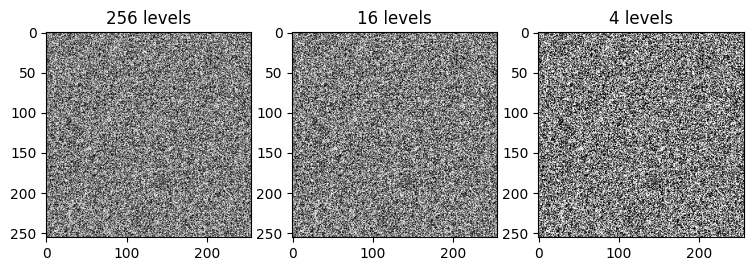

In [ ]:
def quantise (img, levels):
   step = 256 // levels
   return (img // step) * step

q256 = quantise (image, 256)
q16 = quantise (image, 16)
q4 = quantise (image, 4)

plt.figure(figsize= (9,3))
plt.subplot (1,3,1)
plt.imshow(q256, cmap='gray')
plt.title("256 levels")

plt.subplot (1,3,2)
plt.imshow(q16, cmap='gray')
plt.title("16 levels")

plt.subplot (1,3,3)
plt.imshow (q4, cmap='gray')
plt.title("4 levels")
plt.show ()

#1.	At which level does banding become noticeable?
#Banding becomes noticeable at 16 levels, and it is very clear at 4 levels.

#2.	How does this relate to bits per pixel?
#The number of grey levels is related to bits per pixel by: levels = 2^bits.
#Fewer levels mean fewer bits per pixel, resulting in more visible banding


**# Exercise 6.1: Conceptual comparison**
# Using your results from Exercises 4 and 5:

# •	Identify which process affects spatial detail
# •	Identify which process affects intensity smoothness Write a short explanation.

Downsampling affects spatial detail because it reduces the number of pixels (resolution), causing loss of fine details.

Quantization affects intensity smoothness because it reduces the number of grey levels, causing visible banding and less smooth intensity transitions

# Exercise 7.1: N4 and N8 neighbourhoods

N4: [(0, 1), (1, 0), (0, -1), (-1, 0)]
N8: [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]


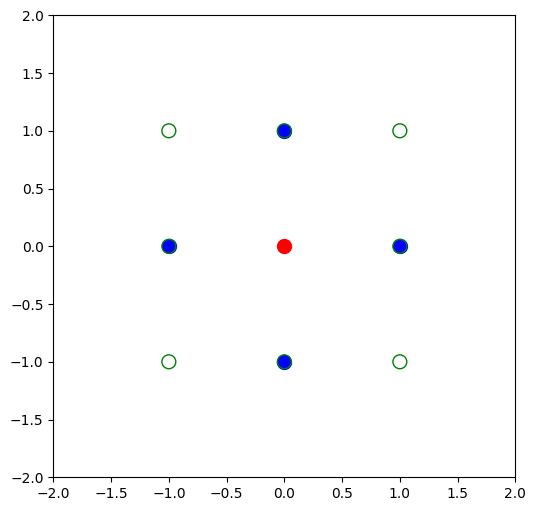

In [ ]:
p = (0,0)
N4 = [(0,1), (1,0), (0,-1), (-1,0)]
N8 = [(0,1), (1,0), (0,-1), (-1,0),
      (1,1), (1,-1), (-1,1), (-1,-1)]
print("N4:", N4)
print("N8:", N8)


plt.figure(figsize=(6,6))
plt.scatter(p[0], p[1], color='red', s=100)
for x, y in N4:
    plt.scatter(p[0]+x, p[1]+y, color='blue', s=100)
for x, y in N8:
    plt.scatter(p[0]+x, p[1]+y, facecolors='none', edgecolors='green', s=100)

plt.xlim(-2,2)
plt.ylim(-2,2)
plt.gca().set_aspect('equal')
plt.show()

# Exercise 8.1: Distance computation

In [ ]:
p = (2, 3)
q = (7, 9)

D_euclid = ((7-2)**2 + (9-3)**2)**0.5
D4 = abs(7-2) + abs(9-3)
D8 = max(abs(7-2), abs(9-3))

print(D_euclid, D4, D8)

#1.	Which distance corresponds to N4 adjacency?
#D4 (Manhattan distance) corresponds to N4 adjacency.

#2.	Which corresponds to N8 adjacency?
#D8 (Chessboard distance) corresponds to N8 adjacency.

7.810249675906654 11 6


# Exercise 9.1: Image translation

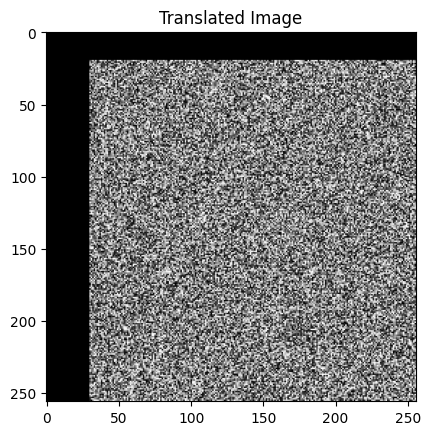

In [ ]:
translated = np.zeros_like(image)
translated[20:, 30:] = image[:-20, :-30]

plt.imshow(translated, cmap='gray')
plt.title("Translated Image")
plt.show()



# Exercise 10.1: Nearest neighbour zoom

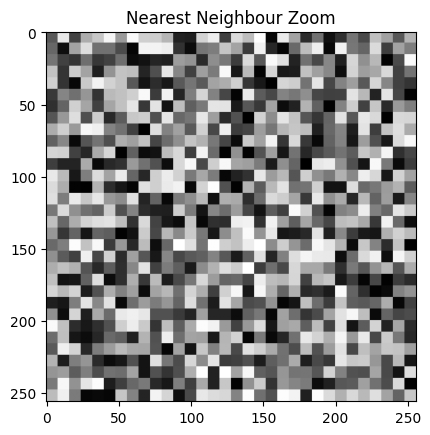

In [ ]:
zoom = np.repeat(np.repeat(down_32, 8, axis=0), 8, axis=1)
plt.imshow(zoom, cmap='gray')
plt.title("Nearest Neighbour Zoom")
plt.show()

#1.	Why does the image appear blocky?
#The image appears blocky because nearest neighbour simply repeats pixel values, creating large uniform blocks.

#2.	Which interpolation method would improve smoothness?
#Bilinear or bicubic interpolation would improve smoothness by averaging surrounding pixels.

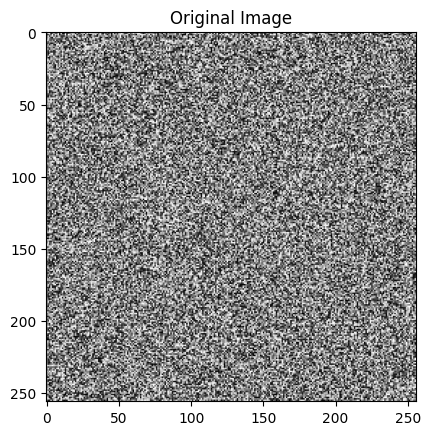

In [ ]:
# start with a grey scale image
image = np.random.randint(0, 256, (256, 256))
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.show()

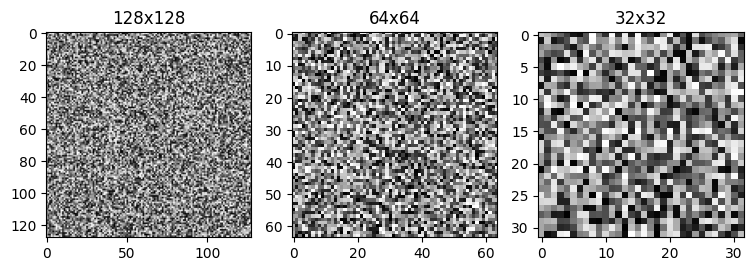

In [ ]:
# create lower spatial resolution images
down_128 = image[::2, ::2]   # 128x128
down_64  = image[::4, ::4]   # 64x64
down_32  = image[::8, ::8]   # 32x32

# show spatial resolution images
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(down_128, cmap='gray')
plt.title("128x128")
plt.subplot(1,3,2)
plt.imshow(down_64, cmap='gray')
plt.title("64x64")
plt.subplot(1,3,3)
plt.imshow(down_32, cmap='gray')
plt.title("32x32")
plt.show()

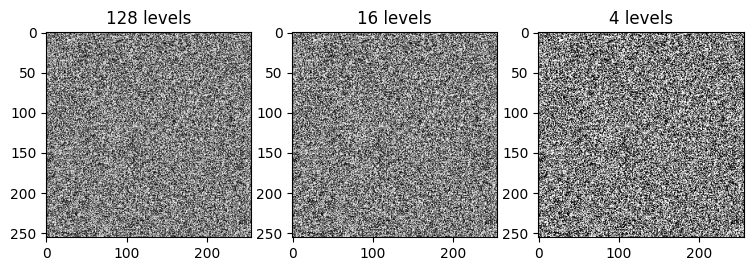

In [ ]:
# function to reduce intensity levels
def quantise(img, levels):
    step = 256 // levels
    return (img // step) * step

q128 = quantise(image, 128)  # 128 levels
q16  = quantise(image, 16)   # 16 levels
q4   = quantise(image, 4)    # 4 levels

# show intensity resolution images
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(q128, cmap='gray')
plt.title("128 levels")
plt.subplot(1,3,2)
plt.imshow(q16, cmap='gray')
plt.title("16 levels")
plt.subplot(1,3,3)
plt.imshow(q4, cmap='gray')
plt.title("4 levels")
plt.show()


 low spatial resolution loses details
 low intensity resolution makes image look bandy
 spatial resolution affects interpretability more